In [1]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

from src.saws_functions import sarg_grid_from_sat  # noqa: E402

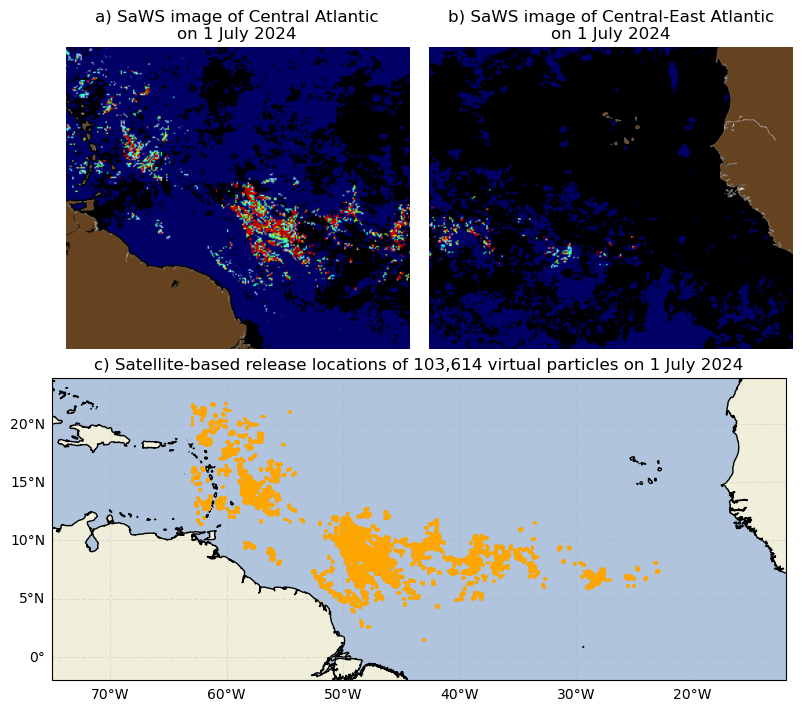

In [2]:
#Loading satellite images
images = [
    {
        'image_name': "../SaWSdata/C20241772024183.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -63.0, -38.0],
    },
    {
        'image_name': "../SaWSdata/C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -38.0, -11.5],
    }
]
sarg_LONGITUDES, sarg_LATITUDES, sarg_AMOUNT = sarg_grid_from_sat(images, coarse=True)

#Creating figure layout: top row = 2 PNG images, bottom row = map
fig = plt.figure(figsize=(10, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

#Top-left: Central Atlantic PNG
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(plt.imread(images[0]['image_name']))
ax1.axis('off')
ax1.set_anchor('E')
ax1.set_title('a) SaWS image of Central Atlantic\non 1 July 2024')

#Top-right: Central-East Atlantic PNG
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(plt.imread(images[1]['image_name']))
ax2.axis('off')
ax2.set_anchor('W')
ax2.set_title('b) SaWS image of Central-East Atlantic\non 1 July 2024')

#Bottom row: map spanning both columns
ax3 = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
ax3.set_facecolor('lightsteelblue')
ax3.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
ax3.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=1)
ax3.gridlines(draw_labels=['left', 'bottom'], zorder=0, alpha=0.3, linestyle='--')
ax3.scatter(sarg_LONGITUDES, sarg_LATITUDES, s=0.1, color='orange', zorder=5)
ax3.set_extent([-75, -12, -2, 21])
ax3.set_title(f'c) Satellite-based release locations of {sarg_AMOUNT:,} virtual particles on 1 July 2024')

fig.savefig('Figures/Figure1.png', bbox_inches='tight', dpi=300)

plt.show()